 Dataset loaded successfully: 180,519 rows × 53 columns



,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_zipcode,product_card_id,product_category_id,product_description,product_image,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


=== Data structure and quality testing ===

 Columns: ['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_description', 'product_image', 'product_name', 'product_pr

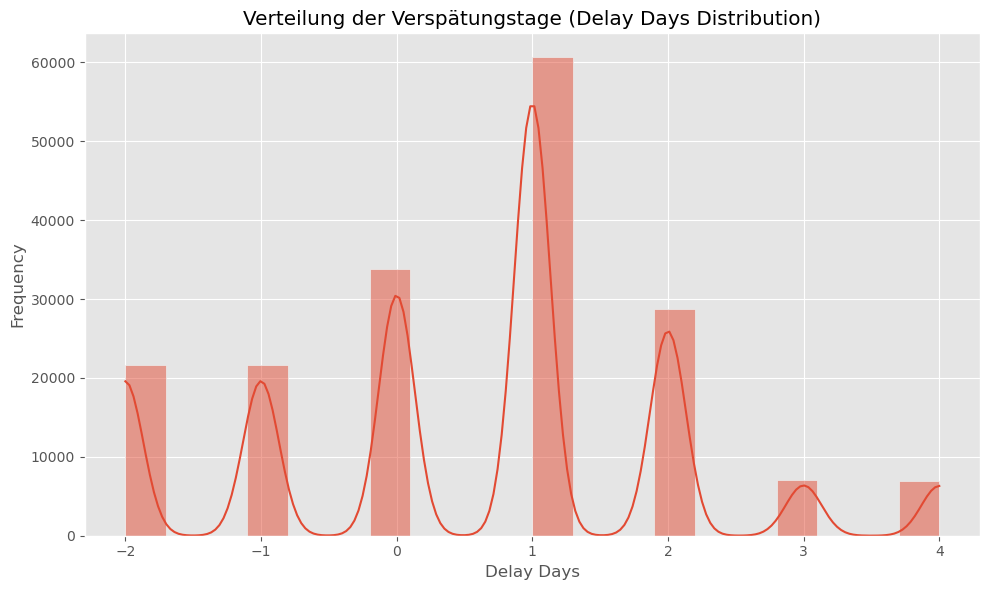

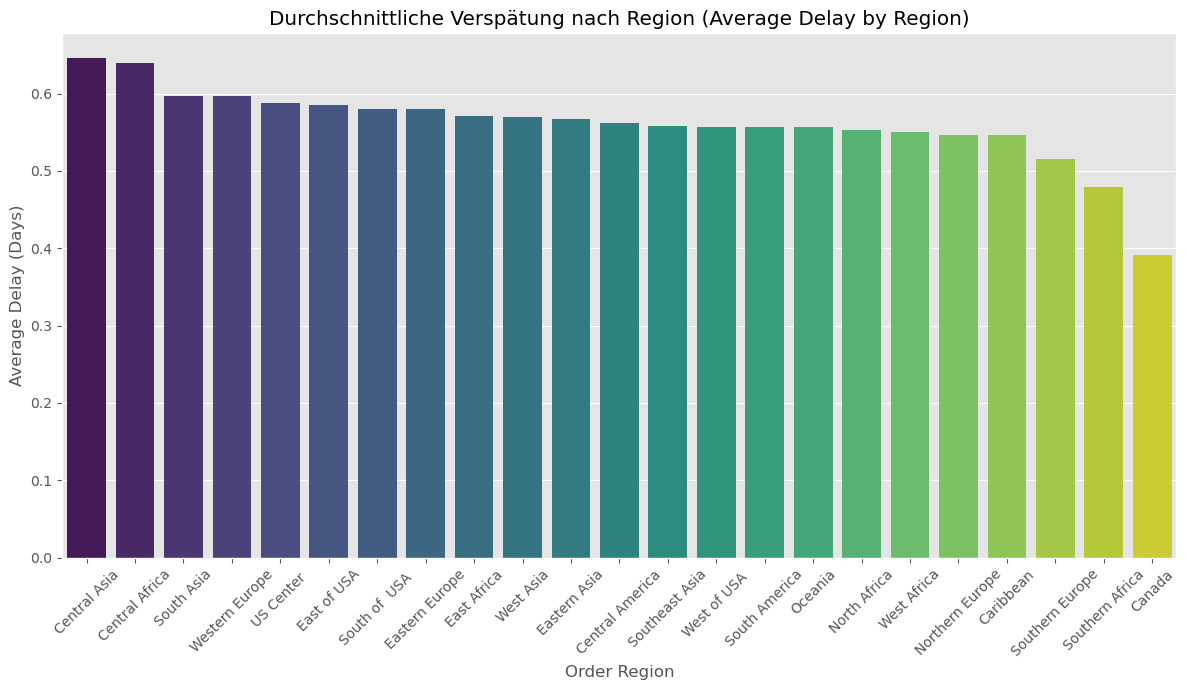

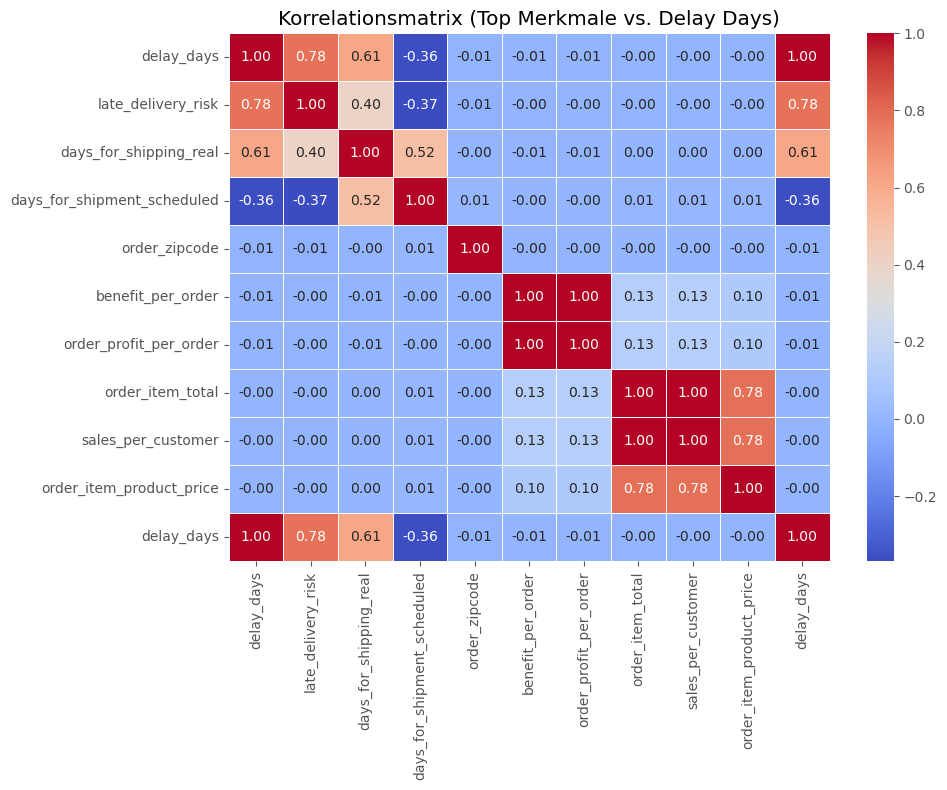


==================== REPORT ====================
# Phase 1: Datenanalyse & KPI-Ergebnisse

##  Key Performance Indicators (KPIs)
- On-Time Delivery Rate: 42.72%
- Average Shipping Cost (sales): $203.77
- Average Benefit per Order: $21.97

##  Engpässe (High Delay Regions)
Overall Average Delay: 0.57 days
Regions with Higher Delays:
 order_region
Central Asia      0.645570
Central Africa    0.639833
South Asia        0.597465
Western Europe    0.597403
US Center         0.587226
East of USA       0.584816
South of  USA     0.579975
Eastern Europe    0.579847
East Africa       0.570734
West Asia         0.569479
Eastern Asia      0.566484

##  Correlation Analysis
Top Factors Increasing Delay:
 delay_days                1.000000
late_delivery_risk        0.777644
days_for_shipping_real    0.613475
customer_id               0.002909
order_customer_id         0.002909
Top Factors Reducing Delay:
 order_profit_per_order        -0.005385
order_zipcode                 -0.005775
days_for_ship

'\nZukünftige Erweiterung (Phase 2 oder 3):\n\nHier kann ein ML-Modell oder ein GNN (Graph Neural Network) eingesetzt werden, um:\n- Lieferverzögerungen vorherzusagen (Predict Delay Probability)\n- Engpässe dynamisch zu erkennen\n- Netzwerkabhängigkeiten zwischen Lieferanten, Regionen und Kunden zu modellieren\n\nVorschläge:\n1. Klassische ML-Modelle:\n   - RandomForestClassifier\n   - XGBoost\n   - LightGBM\n\n2. Graph Neural Networks (GNN):\n   - PyTorch Geometric (z.B. GraphSAGE, GAT)\n   - Ziel: Lieferkette als Graph modellieren (Knoten = Supplier, Kanten = Routen)\n\n→ Dieser Abschnitt bleibt als Template für die nächste Phase.\n'

In [59]:
# ============================================================
# Masterarbeit – Phase 1: Datenanalyse und Engpässe-Erkennung
# ============================================================

# Projekt: DataCo Supply Chain Analytics
# Ziel: Erste Analyse, KPI-Berechnung und Engpässe-Identifikation


# ------------------------------------------------------------
# 1. Bibliotheken importieren
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 2. Datensatz laden
# ------------------------------------------------------------
CSV_PATH = r"/Users/ameraldeiri/Desktop/DataCoSupplyChainDataset.csv"

try:
    # Read dataset
    df_raw = pd.read_csv(CSV_PATH, encoding="ISO-8859-1")

    # Clean column names
    df_raw.columns = (
        df_raw.columns
        .str.strip()                             # remove leading/trailing spaces
        .str.lower()                             # all lower case
        .str.replace(' ', '_')                   # spaces → _
        .str.replace(r'[()]', '', regex=True)    # cleaner regex
    )

    print(f" Dataset loaded successfully: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")
    display(df_raw.head())

except FileNotFoundError:
    print(f" Error: File not found at path: {CSV_PATH}")
except Exception as e:
    print(f" Unexpected error: {e}")


# ------------------------------------------------------------
# 3. Erste Exploration (Deskriptive Statistik)
# ------------------------------------------------------------

print("=== Data structure and quality testing ===")
print("\n Columns:", list(df_raw.columns))
print("\n Data types and non-null counts:")
print(df_raw.info())
print("\n Missing values:")
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print("\n Duplicates:", df_raw.duplicated().sum())


print("\n=== Basic Statistical Overview ===")
print("\n Numerical Variables:")
print(df_raw.describe())

print("\n Categorical Variables:")
print(df_raw.describe(include='object'))


# ------------------------------------------------------------
# 4. Feature Engineering: Zeit und Verspätung
# ------------------------------------------------------------
df_raw['order_date_dateorders'] = pd.to_datetime(df_raw['order_date_dateorders'], errors='coerce')
df_raw['shipping_date_dateorders'] = pd.to_datetime(df_raw['shipping_date_dateorders'], errors='coerce')

# Calculate delay (Verspätung)
df_raw['delay_days'] = df_raw['days_for_shipping_real'] - df_raw['days_for_shipment_scheduled']
df_raw['on_time'] = df_raw['delay_days'] <= 0  # True = On-Time

# ------------------------------------------------------------
# 5. KPI-Berechnung (Key Performance Indicators)
# ------------------------------------------------------------
# KPI 1: On-Time Delivery Rate
on_time_rate = df_raw['on_time'].mean() * 100

# KPI 2: Average Shipping Cost (if available)
if 'shipping_per_order' in df_raw.columns:
    avg_shipping_cost = df_raw['shipping_per_order'].mean()
    cost_col = 'shipping_per_order'
else:
    avg_shipping_cost = df_raw['sales'].mean()
    cost_col = 'sales'

# KPI 3: Average Benefit per Order
avg_benefit = df_raw['benefit_per_order'].mean()

print("\n=== Key Performance Indicators (KPIs) ===")
print(f" On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f" Average Shipping Cost ({cost_col}): ${avg_shipping_cost:.2f}")
print(f" Average Benefit per Order: ${avg_benefit:.2f}")


# ------------------------------------------------------------
# 6. Engpässe-Analyse (Identifying Bottlenecks)
# ------------------------------------------------------------
# Delays by Region
delays_by_region = df_raw.groupby('order_region')['delay_days'].mean().sort_values(ascending=False)
avg_delay = df_raw['delay_days'].mean()
high_delay_regions = delays_by_region[delays_by_region > avg_delay]

print("\n=== Engpässe (High Delay Regions) ===")
print(f"Gesamtdurchschnitt (Overall Avg Delay): {avg_delay:.2f} Tage")
#print(high_delay_regions.to_string()) 


# Analyse regionale Engpässe (Focus on delay_days)
regions_with_differences = []
for region, delay in high_delay_regions.items():
    difference = delay - avg_delay
    regions_with_differences.append((region, delay, difference))

# Sort by difference (from highest to lowest)
regions_with_differences.sort(key=lambda x: x[2], reverse=True)

# Print the results
for region, delay, difference in regions_with_differences:
    print(f"   • {region:<20} {delay:.6f} Tage (+{difference:.6f} über Durchschnitt)")

print("\n ZUSAMMENFASSUNG:")
print(f"   - Anzahl kritischer Regionen: {len(high_delay_regions)}")
print(f"   - Höchste Verzögerung: {high_delay_regions.max():.6f} Tage (Central Asia)")
print(f"   - Niedrigste kritische Verzögerung: {high_delay_regions.min():.6f} Tage (Eastern Asia)")

# Correlation Analysis (Delay Drivers)
numerical_cols = df_raw.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_raw[numerical_cols].corr()
corr_with_delay = corr_matrix['delay_days'].sort_values(ascending=False)

print("\n=== Top 5 Positive Correlations with Delay ===")
print(corr_with_delay.head(5))

print("\n=== Top 5 Negative Correlations with Delay ===")
print(corr_with_delay.tail(5))




# ------------------------------------------------------------
# 7. Visualisierung (Plots)
# ------------------------------------------------------------
plt.style.use('ggplot')

#  Distribution of Delay Days
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['delay_days'], bins=20, kde=True)
plt.title('Verteilung der Verspätungstage (Delay Days Distribution)')
plt.xlabel('Delay Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('delay_distribution.png')
plt.show()

# Average Delay by Region
plt.figure(figsize=(12, 7))
sns.barplot(x=delays_by_region.index, y=delays_by_region.values, palette='viridis')
plt.title('Durchschnittliche Verspätung nach Region (Average Delay by Region)')
plt.xlabel('Order Region')
plt.ylabel('Average Delay (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('delays_by_region.png')
plt.show()

#  Correlation Heatmap
top_corr_cols = corr_with_delay.abs().nlargest(10).index.tolist()
top_corr_cols.append('delay_days')

plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[top_corr_cols].corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.title('Korrelationsmatrix (Top Merkmale vs. Delay Days)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


# ------------------------------------------------------------
# 8. Bericht speichern (für Masterarbeit Dokumentation)
# ------------------------------------------------------------
### with open('phase1_key_findings.md', 'w', encoding='utf-8') as f:
#    f.write("# Phase 1: Datenanalyse & KPI-Ergebnisse\n\n")
#    f.write("##  Key Performance Indicators (KPIs)\n")
#    f.write(f"- On-Time Delivery Rate: {on_time_rate:.2f}%\n")
#    f.write(f"- Average Shipping Cost ({cost_col}): ${avg_shipping_cost:.2f}\n")
#    f.write(f"- Average Benefit per Order: ${avg_benefit:.2f}\n\n")
#    f.write("##  Engpässe (High Delay Regions)\n")
#    f.write(f"Overall Average Delay: {avg_delay:.2f} days\n")
#    f.write(f"Regions with Higher Delays:\n{high_delay_regions.to_string()}\n\n")
#    f.write("##  Correlation Analysis\n")
#    f.write("Top Factors Increasing Delay:\n")
#    f.write(f"{corr_with_delay.head(5).to_string()}\n\n")
#    f.write("Top Factors Reducing Delay:\n")
#    f.write(f"{corr_with_delay.tail(5).to_string()}\n\n")
#    f.write("##  Visualizations\n")
#    f.write("- delay_distribution.png\n- delays_by_region.png\n- correlation_heatmap.png\n")
#    f.write("\n\n_Report generated automatically by Amer Al Deiri’s analysis script._")



print("\n==================== REPORT ====================")
print("# Phase 1: Datenanalyse & KPI-Ergebnisse\n")
print("##  Key Performance Indicators (KPIs)")
print(f"- On-Time Delivery Rate: {on_time_rate:.2f}%")
print(f"- Average Shipping Cost ({cost_col}): ${avg_shipping_cost:.2f}")
print(f"- Average Benefit per Order: ${avg_benefit:.2f}")

print("\n##  Engpässe (High Delay Regions)")
print(f"Overall Average Delay: {avg_delay:.2f} days")
print("Regions with Higher Delays:\n", high_delay_regions.to_string())

print("\n##  Correlation Analysis")
print("Top Factors Increasing Delay:\n", corr_with_delay.head(5).to_string())
print("Top Factors Reducing Delay:\n", corr_with_delay.tail(5).to_string())

print("\n##  Visualizations")
print("Files saved: delay_distribution.png, delays_by_region.png, correlation_heatmap.png")
print("================================================")


# ------------------------------------------------------------
# 9. (Optional) Machine Learning / GNN Perspective
# ------------------------------------------------------------
"""
Zukünftige Erweiterung (Phase 2 oder 3):

Hier kann ein ML-Modell oder ein GNN (Graph Neural Network) eingesetzt werden, um:
- Lieferverzögerungen vorherzusagen (Predict Delay Probability)
- Engpässe dynamisch zu erkennen
- Netzwerkabhängigkeiten zwischen Lieferanten, Regionen und Kunden zu modellieren

Vorschläge:
1. Klassische ML-Modelle:
   - RandomForestClassifier
   - XGBoost
   - LightGBM

2. Graph Neural Networks (GNN):
   - PyTorch Geometric (z.B. GraphSAGE, GAT)
   - Ziel: Lieferkette als Graph modellieren (Knoten = Supplier, Kanten = Routen)

→ Dieser Abschnitt bleibt als Template für die nächste Phase.
"""
